In [136]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
# New imports

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [139]:
Auto = load_data('Auto')
Auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [194]:
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


In [140]:
X = MS(['horsepower']).fit_transform(Auto)
y = Auto['mpg']
model1 = sm.OLS(y,X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


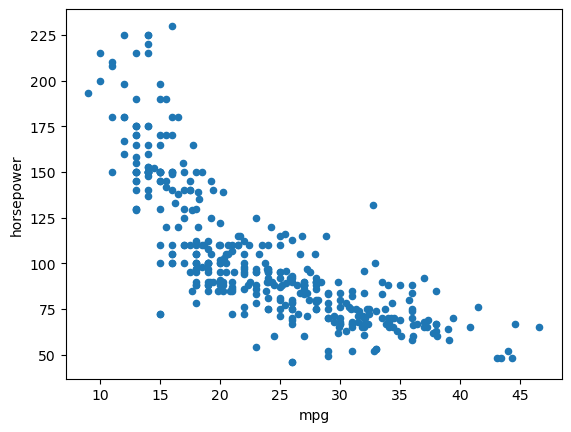

In [141]:
ax = Auto.plot.scatter('mpg', 'horsepower')

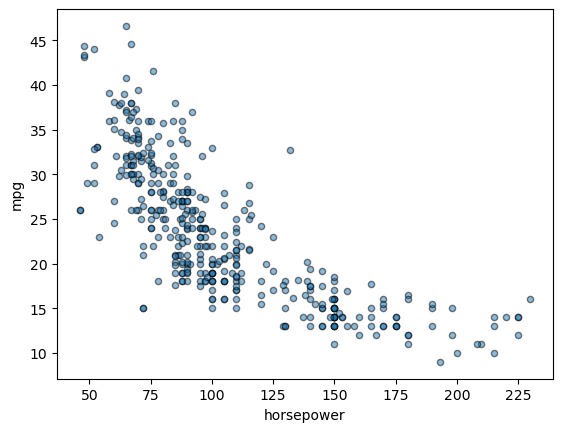

In [163]:
ax = Auto.plot.scatter(x='horsepower', y='mpg', facecolor='None', edgecolor='k', alpha=0.5)

In [164]:
# The function is corrected with a comma in the last line
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs) # Corrected line with comma

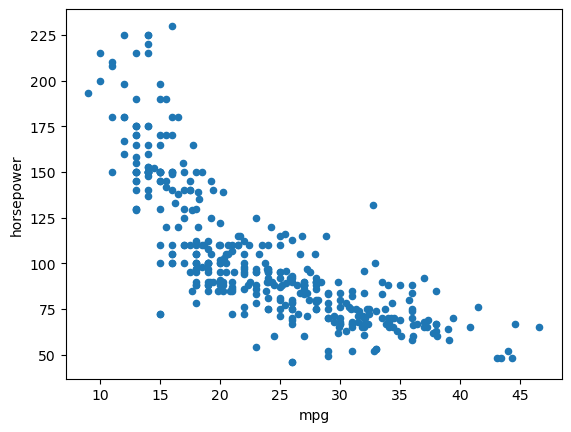

In [165]:
ax = Auto.plot.scatter('mpg', 'horsepower')



In [166]:
abline(ax, results1.params.iloc[0], results1.params.iloc[1], 'r--', linewidth=3)

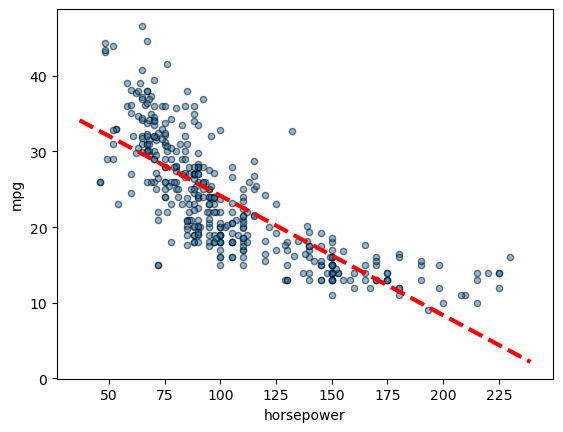

In [168]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS

# Load data and fit the model
Auto = load_data('Auto')
X = MS(['horsepower']).fit_transform(Auto)
y = Auto['mpg']
model1 = sm.OLS(y, X)
results1 = model1.fit()

# 1. Create the scatter plot and get the axes object 'ax'
ax = Auto.plot.scatter(x='horsepower', 
                       y='mpg',
                       facecolor='None',
                       edgecolor='k',
                       alpha=0.5)

# 2. Get the slope and intercept from the model results
intercept = results1.params.iloc[0]
slope = results1.params.iloc[1]

# 3. Create the points for the regression line
#    Get the x-axis limits from the scatter plot
xlim = ax.get_xlim()
#    Calculate the corresponding y-values using y = mx + b
ylim = [slope * xlim[0] + intercept, slope * xlim[1] + intercept]

# 4. Plot the line directly on the 'ax' axes
ax.plot(xlim, ylim, 'r--', linewidth=3)


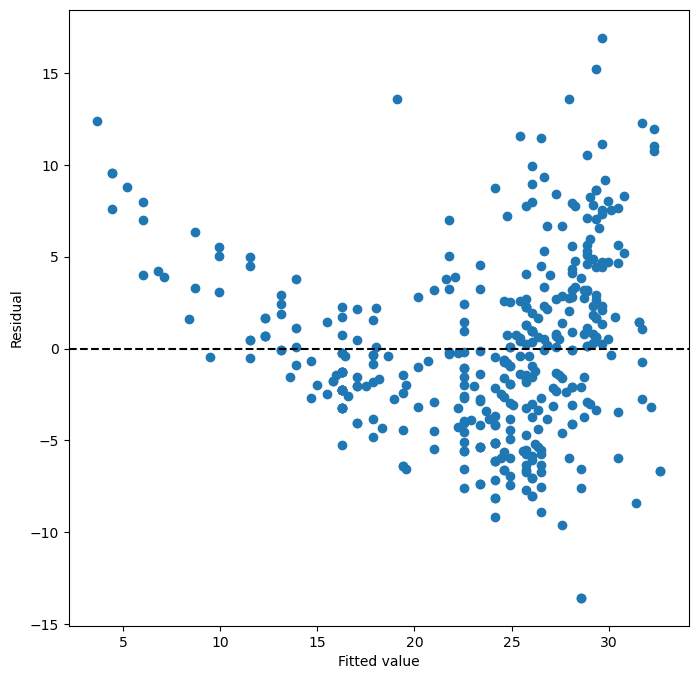

In [169]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results1.fittedvalues, results1.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0,c='k',ls='--')

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='horsepower', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='year', ylabel='mpg'>,
        <Axes: xlabel='origin', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='horsepower', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='year', ylabel='cylinders'>,
        <Axes: xlabel='origin', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement

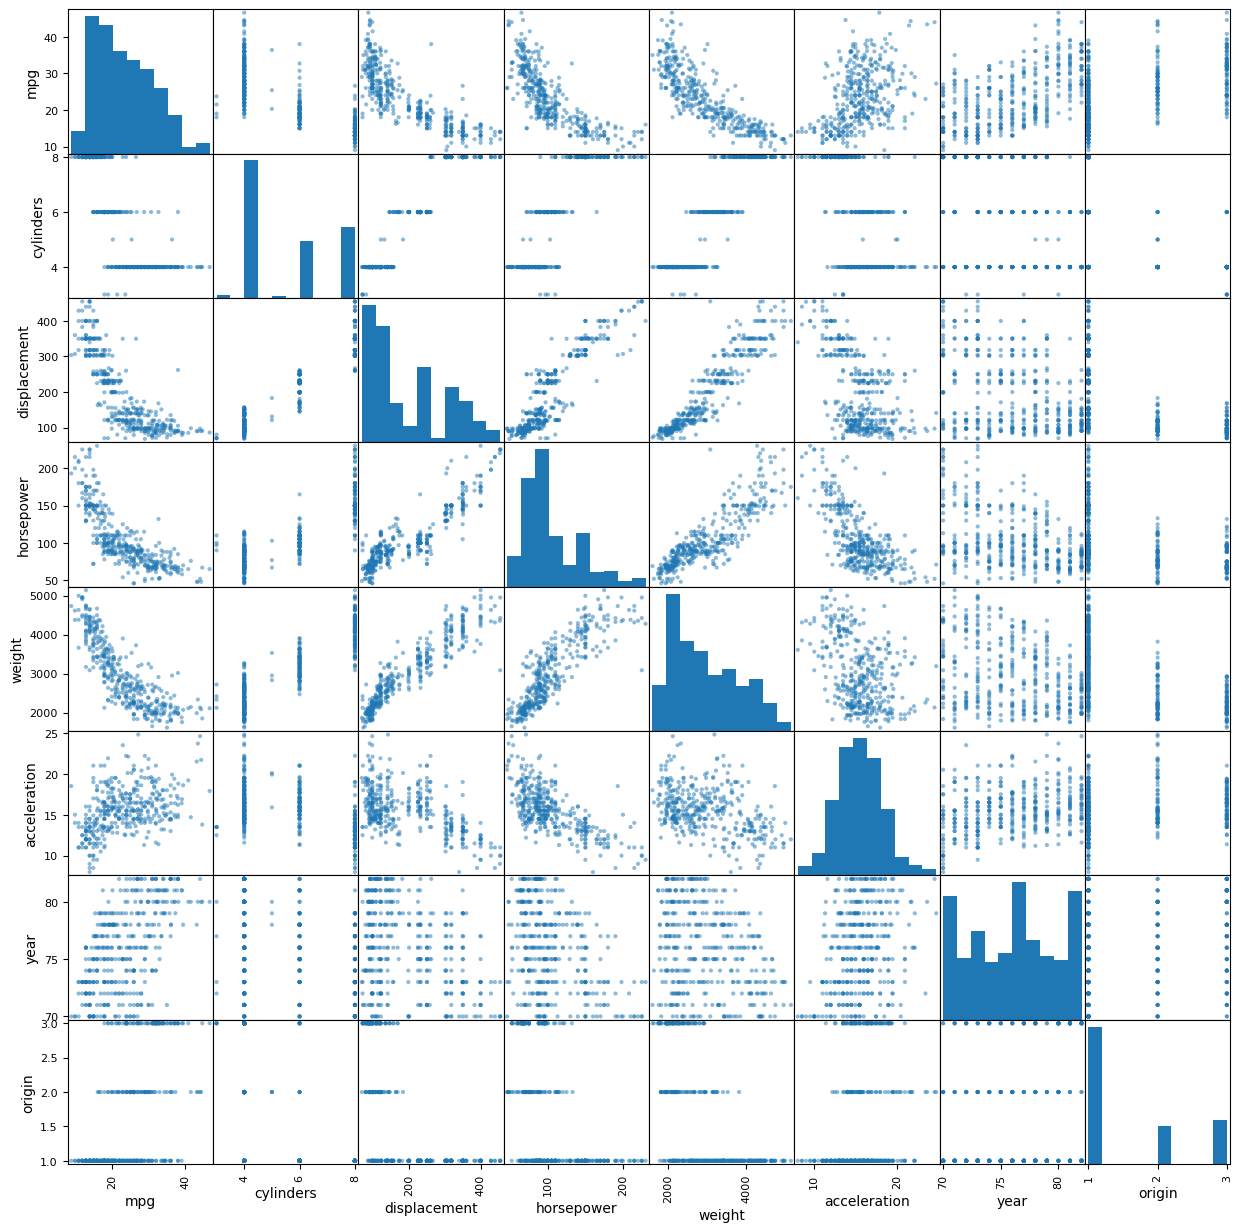

In [173]:
pd.plotting.scatter_matrix(Auto,figsize=(15,15))

In [174]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [177]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [183]:
terms = Auto.columns.drop('mpg')
X = MS(terms).fit_transform(Auto)
y = Auto['mpg']
model1 = sm.OLS(y, X)
results1 = model1.fit()

summarize(results1)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [185]:
X = MS(['horsepower']).fit_transform(Auto)
y = Auto['mpg']
model1 = sm.OLS(y, X)
results2 = model1.fit()

In [186]:
anova_lm(results1,results2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,384.0,4252.212530,0.0,NaN,NaN,NaN
1,390.0,9385.915872,-6.0,-5133.703341,35.552281,NaN


In [192]:
allvars = list(Auto.columns.drop('mpg'))
y = Auto['mpg']
final = allvars + [('displacement', 'horsepower'), ('year','displacement'),('weight','cylinders')]
X = MS(final).fit_transform(Auto)
model3 = sm.OLS(y,X)
summarize(model3.fit())

,coef,std err,t,P>|t|
intercept,-22.6364,8.279000,-2.734,0.007
cylinders,-1.8029,0.820000,-2.199,0.028
displacement,0.1092,0.044000,2.483,0.013
horsepower,-0.1300,0.026000,-5.088,0.000
weight,-0.0085,0.002000,-5.033,0.000
acceleration,-0.0538,0.095000,-0.565,0.573
year,1.0898,0.097000,11.250,0.000
origin,0.6132,0.248000,2.477,0.014
displacement:horsepower,0.0003,0.000073,3.899,0.000
year:displacement,-0.0020,0.001000,-3.906,0.000


In [193]:
anova_lm(results1,model3.fit())

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,384.0,4252.212530,0.0,NaN,NaN,NaN
1,381.0,3070.184981,3.0,1182.02755,48.895262,9.372883e-27
